In [9]:
import warnings
warnings.filterwarnings("ignore")

### 1.Import Data 

In [10]:
from src.data.data import CTScanFolderDataset
from src.transforms.ct_transforms import get_train_transforms,get_eval_transforms

train_transform = get_train_transforms(224)
val_transform = get_eval_transforms(224)

trainDataSet = CTScanFolderDataset("data/train",train_transform)
testDataSet = CTScanFolderDataset("data/test",val_transform)
validDataSet = CTScanFolderDataset("data/valid",val_transform)

print("Number of train samples:", len(trainDataSet))
print("Number of test samples:", len(testDataSet))
print("Number of validation samples:", len(validDataSet))

print("Classes:", trainDataSet.classes)
print("Mapping:", trainDataSet.class_to_idx)

sample = trainDataSet[0]
print(sample["image"].shape)
print(sample["label"])

Number of train samples: 613
Number of test samples: 315
Number of validation samples: 72
Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Mapping: {'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'normal': 2, 'squamous.cell.carcinoma': 3}
torch.Size([3, 224, 224])
0


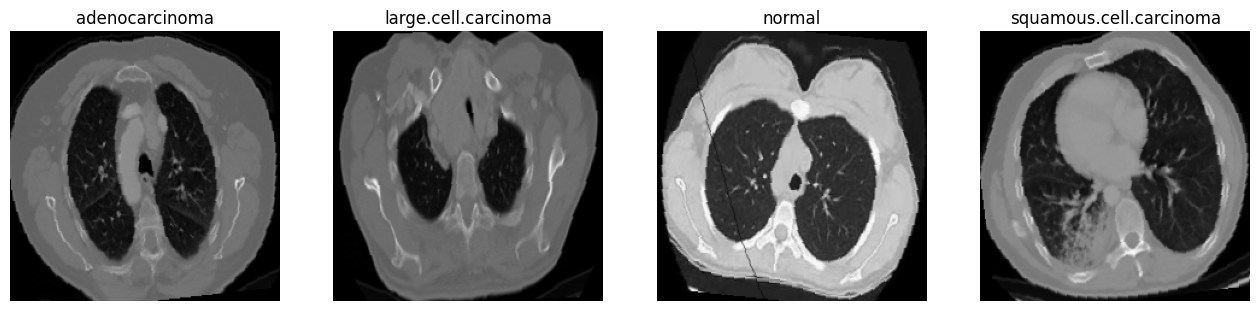

In [11]:
from src.plot.plot import plot_one_image_per_class

plot_one_image_per_class(trainDataSet)

In [12]:
from src.data.dataLoader import create_dataloaders

train_loader, valid_loader, test_loader, classes = create_dataloaders(
    train_dir="data/train",
    valid_dir="data/valid",
    test_dir="data/test",
    image_size=224,
    batch_size=32,
    num_workers=0
)

batch = next(iter(train_loader))

images = batch["image"]
labels = batch["label"]

print("Classes:", classes)
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([0, 1, 0, 1, 0, 3, 0, 3, 1, 0, 2, 1, 3, 0, 0, 0, 2, 1, 0, 1, 3, 3, 3, 2,
        1, 2, 0, 1, 0, 0, 1, 1])


### 2. Check Class Imbalance

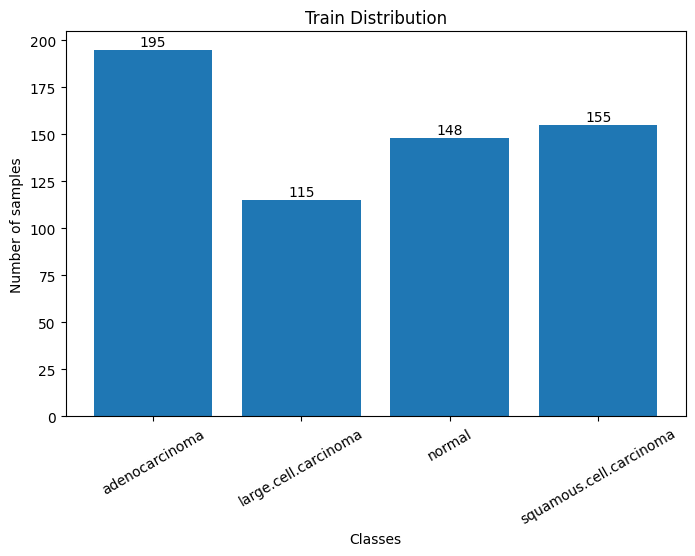

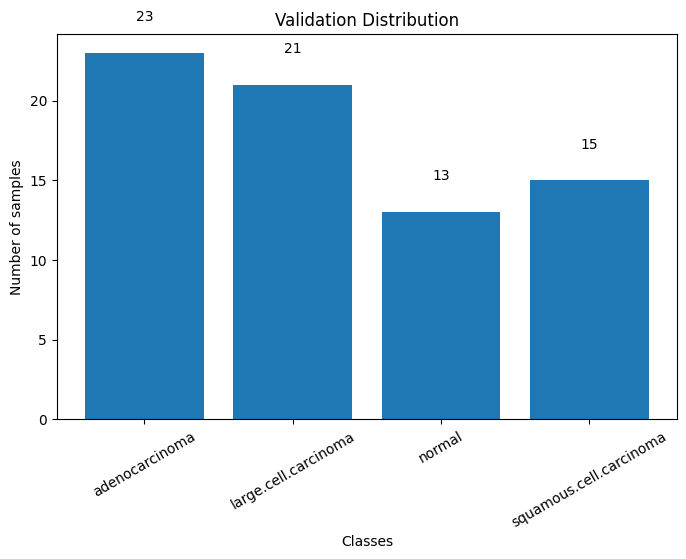

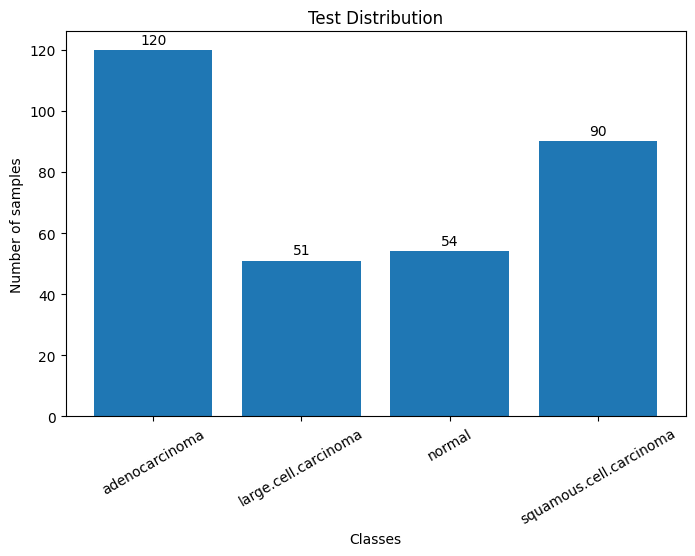

In [13]:
from src.plot.plot import plot_class_distribution

plot_class_distribution(trainDataSet, "Train Distribution")
plot_class_distribution(validDataSet, "Validation Distribution")
plot_class_distribution(testDataSet, "Test Distribution")

In [14]:
import torch
from src.model.cnn_baseline import CNNBaseline

model = CNNBaseline(num_classes=4)

batch = next(iter(train_loader))
images = batch["image"]

outputs = model(images)

print(outputs.shape)

torch.Size([32, 4])


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.model.cnn_baseline import CNNBaseline
from src.training.training import train_one_epoch, validate_one_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNBaseline(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model, valid_loader, criterion, device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")


Epoch 1/10


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.56it/s]


Train Loss: 1.2565 | Train Acc: 0.4600
Valid Loss: 1.3444 | Valid Acc: 0.3056

Epoch 2/10


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.09it/s]


Train Loss: 1.0349 | Train Acc: 0.5449
Valid Loss: 1.1422 | Valid Acc: 0.6250

Epoch 3/10


...

Train Loss: 0.7835 | Train Acc: 0.6574
Valid Loss: 0.9323 | Valid Acc: 0.6944

Epoch 9/10


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.52it/s]


Train Loss: 0.7141 | Train Acc: 0.6852
Valid Loss: 0.9393 | Valid Acc: 0.5972

Epoch 10/10


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.49it/s]

Train Loss: 0.6882 | Train Acc: 0.6884
Valid Loss: 0.9212 | Valid Acc: 0.6111


In [16]:
print("Total params:", model.count_parameters())
print("Trainable params:", model.count_trainable_parameters())

Total params: 3305124
Trainable params: 3305124
